# Projet 11 - Étude de marché Python
## Notebook 1 - Préparation, nettoyage et analyse exploratoire

**Auteur** : Charles Lippens
**Date** : Juillet 2026
**Parcours** : Data Analyst - OpenClassrooms

### Objectif
Préparer un dataset analytique propre et enrichi à partir des sources FAO (Bilans Alimentaires 2017, Population 2000-2018) et **Banque Mondiale** (fichiers CSV bruts téléchargés depuis data.worldbank.org), en vue de l'ACP et du clustering du Notebook 2.

### Contraintes (fiche d'auto-évaluation)
- au moins 8 variables numériques
- au moins 100 pays couverts
- au moins 60 % de la population mondiale
- au moins 3 nouvelles variables via feature engineering (ajout du 27/11/2024)
- 0 valeur manquante dans le dataset final

### Sommaire
1. Imports et configuration
2. Chargement FAO (Bilans Alimentaires + Population)
3. Chargement Banque Mondiale (CSV bruts data.worldbank.org)
4. Pivot de la table FAO en format large
5. Harmonisation des noms de pays (ISO 3166-1 alpha-3)
6. Jointure des sources
7. Diagnostic et traitement des valeurs manquantes
8. Enrichissement par API : taux de change, matières premières, pétrole
9. Feature engineering (au moins 3 nouvelles variables)
10. Sélection finale et contrôle qualité
11. Analyse exploratoire des données
12. Export du dataset analytique


## 1. Imports et configuration

### Deux façons d'exécuter ce notebook

Le notebook tourne de bout en bout sans aucun compte, uniquement à partir des fichiers rangés dans `data/raw`. La connexion FAOSTAT est un confort, pas un prérequis : elle sert seulement à récupérer en direct la table officielle des libellés de pays, au lieu de la lire dans l'export local `fao_pays_regions.csv`. Les chiffres analysés, eux, viennent toujours des fichiers téléchargés, jamais d'une requête.

Le choix se fait avec la variable `MODE_DONNEES` de la cellule suivante :

- `'local'`, la valeur par défaut : aucune question n'est posée et aucun appel n'est fait vers la FAO. Le notebook se déroule d'un bout à l'autre sans intervention, avec ou sans compte, y compris en exécution non surveillée.
- `'auto'` : la cellule d'après propose de saisir un identifiant FAOSTAT, pour qui veut voir la table officielle arriver en direct. Laisser vide et valider bascule sur le fichier local, sans erreur.

On peut aussi fixer le mode depuis l'extérieur du notebook avec la variable d'environnement `P11_MODE`.

Ce réglage ne concerne que la FAO, et il ne change rien aux résultats. La table récupérée en direct et l'export rangé dans `data/raw` sont le même document : seule la ligne de provenance affichée diffère, les 172 pays et tous les chiffres qui suivent sont identiques. Le mot local veut donc dire sans compte FAOSTAT, pas hors ligne.

Le chemin des données n'est pas écrit en dur : la cellule de configuration part du dossier courant et remonte l'arborescence jusqu'au premier niveau qui contient `data/raw`. Le notebook s'exécute donc aussi bien depuis la racine du dossier livré que depuis un sous-dossier, sans rien avoir à déplacer ni à modifier. Si le dossier `data/raw` est absent, la cellule s'arrête tout de suite avec un message explicite plutôt que d'échouer plus loin sur une lecture de fichier.

Les cotations de change de la section 8 sont interrogées dans les deux modes : le dernier service de la cascade est un endpoint public qui ne demande aucune clé. Elles n'alimentent pas l'analyse. La table de taux qui part vers le notebook 2 est un millésime figé au 30 juillet 2026, versionné dans `data/raw`. La cotation du jour est bien récupérée et affichée, mais elle sert de contrôle de fraîcheur : le notebook mesure l'écart au millésime et enregistre le relevé à part, dans `data/processed/fx_du_jour.csv`, sans toucher au fichier d'analyse. Les clusters et les montants du notebook 2 sont donc reproductibles à l'identique, et ce sont exactement ceux du support de présentation.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# racine du projet : on part du dossier courant et on remonte tant qu'on ne trouve pas
# le dossier data/raw. Le notebook s'execute donc quel que soit l'endroit ou il est range,
# a la racine du dossier livre comme dans un sous-dossier notebooks/.
RACINE = next((d for d in [Path.cwd(), *Path.cwd().parents] if (d / 'data' / 'raw').is_dir()), None)
if RACINE is None:
    raise FileNotFoundError(
        "dossier data/raw introuvable en remontant depuis " + Path.cwd().name
        + " : deposer ce notebook dans le dossier decompresse, au meme niveau que data/ ou en dessous"
    )

DATA_RAW = RACINE / 'data' / 'raw'
DATA_PROCESSED = RACINE / 'data' / 'processed'
FIG = RACINE / 'outputs' / 'figures'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

ANNEE_REF = 2017

# mode de recuperation des libelles de pays FAO
#   'local' : valeur par defaut, aucune question, aucun appel FAO, tout vient de data/raw
#   'auto'  : la cellule suivante propose une connexion FAOSTAT, vide = fichier local
# le reglage ne porte que sur la FAO et ne change aucun resultat : la table en ligne et
# l'export local sont le meme document. Les taux de change de la section 8 sont interroges
# dans les deux modes (dernier service ouvert, sans cle) au titre du controle de fraicheur.
MODE_DONNEES = os.environ.get('P11_MODE', 'local').strip().lower()

print(f'Racine du projet detectee : {RACINE.name}')
print(f'Annee de reference : {ANNEE_REF} | mode donnees : {MODE_DONNEES}')

Racine du projet detectee : Etude_de_marche_Python_Lippens_Charles
Annee de reference : 2017 | mode donnees : local


In [2]:
# facultatif : jeton API FAOSTAT (60 min), saisie masquée, rien n'est stocké
# laisser vide et valider pour passer directement au fichier officiel local
# en mode 'local', la question n'est pas posée du tout
import os, requests
from getpass import getpass

if MODE_DONNEES == 'local':
    _id = ''
else:
    try:
        _id = input('identifiant FAOSTAT (vide = fichier local) : ').strip()
    except Exception:
        # exécution non surveillée, sans terminal pour répondre : on prend le fichier local
        _id = ''
        print('aucune saisie possible dans ce contexte : bascule sur le fichier local')
if _id:
    try:
        r = requests.post('https://cognito-idp.eu-west-1.amazonaws.com/',
                          headers={'Content-Type': 'application/x-amz-json-1.1',
                                   'X-Amz-Target': 'AWSCognitoIdentityProviderService.InitiateAuth'},
                          json={'AuthFlow': 'USER_PASSWORD_AUTH',
                                'ClientId': '2csltsigao85ivhp6ojp1aic7o',
                                'AuthParameters': {'USERNAME': _id, 'PASSWORD': getpass('mot de passe : ')}},
                          timeout=10)
        os.environ['FAOSTAT_TOKEN'] = r.json()['AuthenticationResult']['AccessToken']
        print('jeton récupéré, valable 60 minutes')
    except Exception as e:
        print('connexion refusée (' + type(e).__name__ + '), le fichier local prendra le relais')
else:
    print('sans jeton : les libellés de pays viendront de data/raw/fao_pays_regions.csv (export officiel FAO)')

sans jeton : les libellés de pays viendront de data/raw/fao_pays_regions.csv (export officiel FAO)


## 2. Chargement des données FAO

### 2.1 Bilans Alimentaires 2017
Source : FAOSTAT - Domain *New Food Balance Sheets*, année 2017.

In [3]:
fao = pd.read_csv(DATA_RAW / 'DisponibiliteAlimentaire_2017.csv', encoding='utf-8-sig')
print(f'Dimensions  : {fao.shape}')
print(f'Pays uniques: {fao["Zone"].nunique()}')
print(f'Produits    : {fao["Produit"].nunique()}')
print(f'Elements    : {fao["Élément"].nunique()}')
fao.head(3)

Dimensions  : (176600, 14)
Pays uniques: 174
Produits    : 98
Elements    : 17


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,"4,281.00",S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,"2,302.00",S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.00,S,Données standardisées


### 2.2 Population (2017 et 2007 pour la croissance démographique)

In [4]:
pop = pd.read_csv(DATA_RAW / 'Population_2000_2018.csv', encoding='utf-8-sig')
pop_2017 = pop[pop['Année'] == 2017][['Zone', 'Valeur']].rename(columns={'Valeur': 'population_2017_milliers'})
pop_2007 = pop[pop['Année'] == 2007][['Zone', 'Valeur']].rename(columns={'Valeur': 'population_2007_milliers'})
print(f'Pays population 2017: {pop_2017["Zone"].nunique()}')
print(f'Pays population 2007: {pop_2007["Zone"].nunique()}')

Pays population 2017: 236
Pays population 2007: 230


## 3. Chargement des données Banque Mondiale (CSV bruts data.worldbank.org)

Les fichiers de data.worldbank.org ont tous la même structure : 4 lignes d'en-tête, puis Country Name, Country Code, Indicator Name, Indicator Code et une colonne par année. Le code repère chaque fichier par son code indicateur. Le nom du fichier n'a pas d'importance.

### Récupérer les fichiers BM (si absents)
Les 4 indicateurs (NY.GDP.PCAP.CD, NY.GDP.MKTP.KD.ZG, FP.CPI.TOTL.ZG, PV.EST) se téléchargent sur data.worldbank.org. Les CSV API_*.csv vont dans data/raw/. Si rien n'est trouvé, le notebook bascule sur le fichier consolidé banque_mondiale_2017.csv fourni en exemple.

In [5]:
def load_wb_indicator_raw(code, value_name, year=ANNEE_REF, data_dir=DATA_RAW):
    '''
    Charge un indicateur Banque Mondiale depuis un CSV brut.
    Gere automatiquement les 2 formats :
      - API directe data.worldbank.org : API_*.csv avec 4 lignes d\'en-tete, colonne "2017"
      - DataBank : Data*.csv sans skiprows, colonne "2017 [YR2017]"
    Cherche le fichier dont le nom contient le code indicateur.
    Exclut les fichiers Metadata_ et les .bak.
    Renvoie un DataFrame avec colonnes : iso3, pays_bm, [value_name]
    '''
    import os
    pattern = str(data_dir / f'*{code}*.csv')
    all_files = glob.glob(pattern)
    # Exclure les fichiers Metadata et les backups
    files = [f for f in all_files if 'Metadata' not in os.path.basename(f)
             and not f.endswith('.bak')]

    if not files:
        return None

    # Si plusieurs fichiers, on prend le plus récent (modification)
    files.sort(key=os.path.getmtime, reverse=True)
    fp = files[0]

    # Détection du format : on lit la 1ere ligne
    with open(fp, 'r', encoding='utf-8-sig') as f:
        first_line = f.readline().strip()

    if first_line.startswith('"Data Source"') or first_line.startswith('Data Source'):
        # Format API directe : 4 lignes d\'en-tete
        df = pd.read_csv(fp, skiprows=4)
        year_col = str(year)
    elif first_line.startswith('Country Name,Country Code,Series'):
        # Format DataBank : pas de skiprows
        df = pd.read_csv(fp)
        year_col = f'{year} [YR{year}]'
    else:
        # Fallback
        df = pd.read_csv(fp)
        year_col = str(year) if str(year) in df.columns else f'{year} [YR{year}]'

    if year_col not in df.columns:
        print(f'  [!] {code}: colonne {year_col} absente du fichier {os.path.basename(fp)}')
        return None

    # Conversion robuste (DataBank utilise ".." pour les NaN)
    df[year_col] = pd.to_numeric(df[year_col], errors='coerce')

    out = df[['Country Name', 'Country Code', year_col]].rename(
        columns={'Country Name': 'pays_bm', 'Country Code': 'iso3', year_col: value_name}
    )
    out = out.dropna(subset=['iso3'])
    return out

indicators_bm = {
    'NY.GDP.PCAP.CD'    : 'pib_par_hab_usd',
    'NY.GDP.MKTP.KD.ZG' : 'croissance_pib',
    'FP.CPI.TOTL.ZG'    : 'inflation',
    'PV.EST'            : 'stabilite_politique',
    # Optionnels - chargees si presents
    'SP.URB.TOTL.IN.ZS' : 'part_urbaine_pct',
    'EN.ATM.CO2E.PC'    : 'co2_par_hab',
}

bm_indics = {}
for code, name in indicators_bm.items():
    df_ind = load_wb_indicator_raw(code, name)
    if df_ind is not None:
        bm_indics[name] = df_ind
        n_valides = df_ind[name].notna().sum()
        # Affiche aussi min/max pour contrôle
        vmin = df_ind[name].min()
        vmax = df_ind[name].max()
        print(f'  [OK] {code:25s} -> {name:25s} : {n_valides:3d} pays | min={vmin:.2f}, max={vmax:.2f}')
    else:
        print(f'  [..] {code:25s} -> fichier non trouve dans data/raw/')

print(f'\nIndicateurs BM charges (CSV bruts) : {len(bm_indics)}')


  [OK] NY.GDP.PCAP.CD            -> pib_par_hab_usd           : 259 pays | min=246.06, max=170663.38
  [OK] NY.GDP.MKTP.KD.ZG         -> croissance_pib            : 258 pays | min=-15.67, max=74.59
  [OK] FP.CPI.TOTL.ZG            -> inflation                 : 186 pays | min=-1.54, max=187.85
  [OK] PV.EST                    -> stabilite_politique       : 212 pays | min=-2.73, max=1.75
  [..] SP.URB.TOTL.IN.ZS         -> fichier non trouve dans data/raw/
  [..] EN.ATM.CO2E.PC            -> fichier non trouve dans data/raw/

Indicateurs BM charges (CSV bruts) : 4


### 3.1 Fusion des indicateurs BM en un seul DataFrame

In [6]:
if bm_indics:
    # Fusion progressive des indicateurs BM trouves
    bm = None
    for name, dfi in bm_indics.items():
        if bm is None:
            bm = dfi
        else:
            bm = bm.merge(dfi[['iso3', name]], on='iso3', how='outer')
    print(f'Fichier BM fusionne : {bm.shape}')
    print(f'Couverture pays : {bm["iso3"].nunique()}')
else:
    # FALLBACK : utiliser le CSV consolide fourni en exemple
    print('[!] Aucun fichier BM brut trouve. Utilisation du fallback banque_mondiale_2017.csv')
    print('    Pour les donnees officielles : data.worldbank.org, un CSV par code indicateur,')
    print('    a deposer tel quel dans data/raw/ (le nom API_[CODE]_... est reconnu automatiquement).')
    bm = pd.read_csv(DATA_RAW / 'banque_mondiale_2017.csv')

print('\nColonnes BM :')
print(bm.columns.tolist())
bm.head()

Fichier BM fusionne : (275, 6)
Couverture pays : 275

Colonnes BM :
['pays_bm', 'iso3', 'pib_par_hab_usd', 'croissance_pib', 'inflation', 'stabilite_politique']


,pays_bm,iso3,pib_par_hab_usd,croissance_pib,inflation,stabilite_politique
0,Aruba,ABW,"28,440.04",3.49,-1.03,1.21
1,Africa Eastern and Southern,AFE,"1,528.10",2.68,6.22,NaN
2,Afghanistan,AFG,525.47,2.65,4.98,-2.61
3,Africa Western and Central,AFW,"1,574.23",2.30,1.73,NaN
4,Angola,AGO,"2,790.72",-0.15,29.84,-0.54


## 4. Pivot de la table FAO en format large

### 4.1 Filtrage sur les produits cibles

In [7]:
produits_cibles = [
    'Viande de Volailles',
    'Viande de Bovins',
    'Viande de Suides',
    "Viande d'Ovins/Caprins",
    'Oeufs',
]
fao_f = fao[fao['Produit'].isin(produits_cibles)].copy()
print(f'Lignes apres filtre produits : {len(fao_f):,}')
fao_f['Produit'].value_counts()

Lignes apres filtre produits : 10,397


Produit
Oeufs                     2347
Viande de Bovins          2065
Viande de Volailles       2061
Viande de Suides          2009
Viande d'Ovins/Caprins    1915
Name: count, dtype: int64

### 4.2 Filtrage sur les éléments utiles

In [8]:
elements_cibles = [
    'Production',
    'Importations - Quantité',
    'Exportations - Quantité',
    'Disponibilité alimentaire (Kcal/personne/jour)',
    'Disponibilité alimentaire en quantité (kg/personne/an)',
    'Disponibilité de protéines en quantité (g/personne/jour)',
    'Disponibilité de matière grasse en quantité (g/personne/jour)',
]
fao_f = fao_f[fao_f['Élément'].isin(elements_cibles)].copy()
print(f'Lignes apres filtre elements : {len(fao_f):,}')

Lignes apres filtre elements : 5,687


### 4.3 Pivot : une ligne par pays, une colonne par couple (produit, élément)

In [9]:
def short_name(prod, elt):
    p = prod.replace(' ', '_').replace("'", '').lower()
    e = elt.split('(')[0].strip().replace(' ', '_').replace('-', '').lower().replace('__', '_')
    return f'{p}__{e}'

fao_pivot = fao_f.pivot_table(index='Zone', columns=['Produit', 'Élément'], values='Valeur', aggfunc='sum')
fao_pivot.columns = [short_name(p, e) for p, e in fao_pivot.columns]
fao_pivot = fao_pivot.reset_index().rename(columns={'Zone': 'pays_fao'})
print(f'Forme du pivot : {fao_pivot.shape}')
print(f'Exemple de colonnes : {list(fao_pivot.columns[:6])}')

Forme du pivot : (172, 36)
Exemple de colonnes : ['pays_fao', 'oeufs__disponibilité_alimentaire', 'oeufs__disponibilité_alimentaire_en_quantité', 'oeufs__disponibilité_de_matière_grasse_en_quantité', 'oeufs__disponibilité_de_protéines_en_quantité', 'oeufs__exportations_quantité']


## 5. Harmonisation des noms de pays (ISO 3166-1 alpha-3)

La clé de jointure est le code ISO 3166-1 alpha-3 (FRA, USA, CHN...). La Banque mondiale le fournit déjà (colonne Country Code). Reste la FAO : noms en français, sans code ISO.

Trois niveaux, du plus frais au plus sûr : l'API FAOSTAT (jeton gratuit, en mode auto seulement), l'export officiel du site versionné dans data/raw, puis pycountry en dernier filet. Le dictionnaire de corrections manuelles a été retiré, la table officielle le remplace. Tous les noms passent par une normalisation des espaces avant comparaison, et la source utilisée s'affiche à l'exécution.

In [10]:
!pip install -q pycountry

In [11]:
# noms FAO -> ISO3 : API FAOSTAT (jeton), sinon export officiel local, sinon pycountry
import os
import pycountry
import gettext

def normalise(s):
    """Ramene tous les espaces (dont doubles et insecables) a un espace simple."""
    return ' '.join(str(s).replace(' ', ' ').split())

def table_faostat_iso3():
    """Table officielle FAO : libelles francais -> ISO3. 1) API (jeton), 2) fichier local."""
    import requests
    # portail developpeur FAOSTAT, jeton a duree courte ; vide en mode local
    jeton = '' if MODE_DONNEES == 'local' else os.environ.get('FAOSTAT_TOKEN', '')
    if jeton:
        entetes = {'Authorization': 'Bearer ' + jeton, 'User-Agent': 'Mozilla/5.0'}
        for hote in ['https://faostatservices.fao.org/api/v1/fr/definitions/types/area?datasource=DB4',
                     'https://fenixservices.fao.org/faostat/api/v1/fr/definitions/types/area?datasource=DB4']:
            try:
                lignes = requests.get(hote, headers=entetes, timeout=15).json()['data']
                cle_iso3 = next(k for k in lignes[0] if 'ISO3' in k.upper())
                cle_nom = next(k for k in lignes[0] if k.strip().lower() in ('country', 'pays', 'area', 'zone'))
                return {normalise(l[cle_nom]): str(l[cle_iso3]).strip() for l in lignes
                        if l.get(cle_iso3) and len(str(l[cle_iso3]).strip()) == 3}, 'API (jeton)'
            except Exception:
                continue
    local = DATA_RAW / 'fao_pays_regions.csv'     # export officiel du site, versionne avec le projet
    if local.exists():
        t = pd.read_csv(local, encoding='utf-8-sig')
        cle_iso3 = next(c for c in t.columns if 'ISO3' in c.upper())
        cle_nom = next(c for c in t.columns if c.strip().lower() in ('pays', 'country', 'zone', 'area'))
        t = t[[cle_nom, cle_iso3]].dropna()
        return {normalise(n): str(i).strip() for n, i in zip(t[cle_nom], t[cle_iso3])
                if len(str(i).strip()) == 3}, 'fichier officiel local'
    raise RuntimeError('ni jeton API, ni fichier officiel')

try:
    fao_officiel, origine = table_faostat_iso3()
    source_corres = f'table officielle FAOSTAT, {origine} ({len(fao_officiel)} libelles)'
except Exception:
    fao_officiel = {}
    source_corres = 'repli hors ligne : pycountry'

# repli hors ligne : pycountry (norme ISO, traductions francaises officielles)
trad_fr = gettext.translation('iso3166-1', pycountry.LOCALES_DIR, languages=['fr'])
fr_to_iso = {normalise(trad_fr.gettext(c.name)): c.alpha_3 for c in pycountry.countries}

def to_iso3(name):
    if pd.isna(name): return np.nan
    name = normalise(name)
    if name in fao_officiel: return fao_officiel[name]
    if name in fr_to_iso: return fr_to_iso[name]
    try: return pycountry.countries.lookup(name).alpha_3
    except LookupError: return np.nan

fao_pivot['iso3'] = fao_pivot['pays_fao'].apply(to_iso3)
pop_2017['iso3'] = pop_2017['Zone'].apply(to_iso3)
pop_2007['iso3'] = pop_2007['Zone'].apply(to_iso3)

print('Correspondance :', source_corres)
print(f'FAO avec iso3   : {fao_pivot["iso3"].notna().sum()} / {len(fao_pivot)}')
print(f'POP 2017 iso3   : {pop_2017["iso3"].notna().sum()} / {len(pop_2017)}')

non_resolus = fao_pivot[fao_pivot['iso3'].isna()]['pays_fao'].tolist()
if non_resolus:
    print(f'\nNon resolus (probablement agregats regionaux) : {non_resolus[:10]}')

Correspondance : table officielle FAOSTAT, fichier officiel local (263 libelles)
FAO avec iso3   : 172 / 172
POP 2017 iso3   : 236 / 236


In [12]:
pop_2017[pop_2017['iso3'].isna()]['Zone']

Series([], Name: Zone, dtype: object)

## 6. Jointure des sources sur la clé `iso3`

In [13]:
# Suppression des agrégats régionaux (iso3 = NaN)
fao_pivot = fao_pivot.dropna(subset=['iso3']).copy()
pop_2017 = pop_2017.dropna(subset=['iso3']).copy()
pop_2007 = pop_2007.dropna(subset=['iso3']).copy()

# Eviter les doublons iso3
fao_pivot = fao_pivot.drop_duplicates(subset=['iso3'])
pop_2017 = pop_2017.drop_duplicates(subset=['iso3'])
pop_2007 = pop_2007.drop_duplicates(subset=['iso3'])
bm = bm.drop_duplicates(subset=['iso3'])

df = (
    fao_pivot
    .merge(pop_2017[['iso3', 'population_2017_milliers']], on='iso3', how='left')
    .merge(pop_2007[['iso3', 'population_2007_milliers']], on='iso3', how='left')
    .merge(bm, on='iso3', how='left')
)

df['pays'] = df['pays_bm'].fillna(df['pays_fao'])
df = df.drop(columns=['pays_fao', 'pays_bm'])

print(f'Pays apres jointures : {df.shape[0]}')
print(f'Variables : {df.shape[1]}')
df.head(2)

Pays apres jointures : 172
Variables : 43


,oeufs__disponibilité_alimentaire,oeufs__disponibilité_alimentaire_en_quantité,oeufs__disponibilité_de_matière_grasse_en_quantité,oeufs__disponibilité_de_protéines_en_quantité,oeufs__exportations_quantité,oeufs__importations_quantité,oeufs__production,viande_dovins/caprins__disponibilité_alimentaire,viande_dovins/caprins__disponibilité_alimentaire_en_quantité,viande_dovins/caprins__disponibilité_de_matière_grasse_en_quantité,viande_dovins/caprins__disponibilité_de_protéines_en_quantité,viande_dovins/caprins__exportations_quantité,viande_dovins/caprins__importations_quantité,viande_dovins/caprins__production,viande_de_bovins__disponibilité_alimentaire,viande_de_bovins__disponibilité_alimentaire_en_quantité,viande_de_bovins__disponibilité_de_matière_grasse_en_quantité,viande_de_bovins__disponibilité_de_protéines_en_quantité,viande_de_bovins__exportations_quantité,viande_de_bovins__importations_quantité,viande_de_bovins__production,viande_de_suides__disponibilité_alimentaire,viande_de_suides__disponibilité_alimentaire_en_quantité,viande_de_suides__disponibilité_de_matière_grasse_en_quantité,viande_de_suides__disponibilité_de_protéines_en_quantité,viande_de_suides__exportations_quantité,viande_de_suides__importations_quantité,viande_de_suides__production,viande_de_volailles__disponibilité_alimentaire,viande_de_volailles__disponibilité_alimentaire_en_quantité,viande_de_volailles__disponibilité_de_matière_grasse_en_quantité,viande_de_volailles__disponibilité_de_protéines_en_quantité,viande_de_volailles__exportations_quantité,viande_de_volailles__importations_quantité,viande_de_volailles__production,iso3,population_2017_milliers,population_2007_milliers,pib_par_hab_usd,croissance_pib,inflation,stabilite_politique,pays
0,6.00,1.50,0.42,0.44,0.00,54.00,20.00,26.00,4.15,2.16,1.62,NaN,0.00,160.00,15.00,2.61,1.20,1.09,NaN,6.00,94.00,0.00,0.00,0.01,0.00,NaN,0.00,NaN,5.00,1.53,0.33,0.54,NaN,29.00,28.00,AFG,"36,296.11","27,100.54",525.47,2.65,4.98,-2.61,Afghanistan
1,26.00,6.61,1.80,2.07,15.00,2.00,433.00,18.00,2.88,1.52,1.00,1.00,7.00,167.00,102.00,16.57,8.19,6.64,46.00,20.00,"1,018.00",43.00,4.19,4.18,1.12,29.00,29.00,235.00,143.00,35.69,9.25,14.11,63.00,514.00,"1,667.00",ZAF,"57,009.76","49,119.76","6,618.34",1.16,5.19,-0.38,South Africa


## 7. Diagnostic et traitement des valeurs manquantes

In [14]:
nan_par_var = df.isna().sum().sort_values(ascending=False)
nan_par_var = nan_par_var[nan_par_var > 0]
print('Variables avec valeurs manquantes :')
print(nan_par_var.head(15))

Variables avec valeurs manquantes :
viande_dovins/caprins__exportations_quantité    78
oeufs__exportations_quantité                    58
viande_de_suides__exportations_quantité         50
viande_de_bovins__exportations_quantité         41
viande_de_volailles__exportations_quantité      37
viande_dovins/caprins__importations_quantité    14
viande_de_suides__production                    14
inflation                                       10
viande_dovins/caprins__production                8
oeufs__importations_quantité                     4
oeufs__production                                4
viande_de_volailles__production                  4
viande_de_bovins__production                     4
viande_de_suides__importations_quantité          4
croissance_pib                                   3
dtype: int64


### 7.1 Stratégie d'imputation

Deux règles.

Les flux FAO (production, importations, exportations, disponibilités) : NaN devient 0. Un flux non déclaré, c'est une absence de flux. Hypothèse métier, pas une valeur inventée.

Les variables Banque mondiale (PIB par habitant, croissance, inflation, stabilité politique) : NaN veut dire non publié pour 2017. J'impute avec la médiane mondiale.


In [15]:
# ecart médiane / moyenne sur les variables economiques
for c in ['pib_par_hab_usd', 'croissance_pib', 'inflation', 'stabilite_politique']:
    if c in df.columns:
        print(f'{c:22s} mediane = {df[c].median():>10,.2f}   moyenne = {df[c].mean():>10,.2f}')

pib_par_hab_usd        mediane =   6,025.23   moyenne =  14,189.16
croissance_pib         mediane =       3.40   moyenne =       3.35
inflation              mediane =       2.41   moyenne =       4.14
stabilite_politique    mediane =      -0.02   moyenne =      -0.08


In [16]:
cols_fao = df.filter(regex='production|importations|exportations|disponibilit').columns
df[cols_fao] = df[cols_fao].fillna(0)

# Liste etendue des colonnes BM possibles
cols_med = ['pib_par_hab_usd', 'croissance_pib', 'inflation', 'stabilite_politique',
            'part_urbaine_pct', 'co2_par_hab',
            'population_2017_milliers', 'population_2007_milliers']
for c in cols_med:
    if c in df.columns:
        med = df[c].median()
        n = df[c].isna().sum()
        df[c] = df[c].fillna(med)
        if n > 0:
            print(f'{c:30s} : {n:3d} valeurs imputees (mediane = {med:,.2f})')

print(f'\nTotal NaN restants : {df.isna().sum().sum()}')

pib_par_hab_usd                :   2 valeurs imputees (mediane = 6,025.23)
croissance_pib                 :   3 valeurs imputees (mediane = 3.40)
inflation                      :  10 valeurs imputees (mediane = 2.41)
stabilite_politique            :   2 valeurs imputees (mediane = -0.02)
population_2007_milliers       :   1 valeurs imputees (mediane = 8,724.24)

Total NaN restants : 0


## 8. Enrichissement par API : taux de change, matières premières, pétrole


In [17]:
!pip install -q yfinance babel

In [18]:
# relevé live : Yahoo d'abord, Twelve Data en secours pour le change, sinon repli
import os, datetime
import pandas as pd

INDICATEURS = {
    'EUR/USD': 'EURUSD=X', 'EUR/JPY': 'EURJPY=X', 'EUR/GBP': 'EURGBP=X', 'EUR/CNY': 'EURCNY=X',
    'Mais': 'ZC=F', 'Soja': 'ZS=F', 'Ble': 'ZW=F',   # futures Chicago, cents/boisseau
    'Brent': 'BZ=F',                                  # USD/baril
}
SNAPSHOT = {'EUR/USD': 1.154, 'EUR/JPY': 183.4, 'EUR/GBP': 0.856, 'EUR/CNY': 7.79,
            'Mais': 468.5, 'Soja': 1188.5, 'Ble': 663.5, 'Brent': 89.0}   # repli 30 juillet 2026
CLE_TD = os.environ.get('TWELVEDATA_API_KEY', '')

def valeur_live(nom):
    """Yahoo, sinon Twelve Data (change), sinon repli."""
    try:
        import yfinance as yf
        h = yf.Ticker(INDICATEURS[nom]).history(period='1d', interval='1m')
        return round(float(h['Close'].dropna().iloc[-1]), 4), 'Yahoo'
    except Exception:
        pass
    if '/' in nom and CLE_TD:
        try:
            import requests
            r = requests.get('https://api.twelvedata.com/price',
                             params={'symbol': nom, 'apikey': CLE_TD}, timeout=5)
            return round(float(r.json()['price']), 4), 'Twelve Data'
        except Exception:
            pass
    return SNAPSHOT[nom], 'repli'

releve = {n: valeur_live(n) for n in INDICATEURS}
horodatage = datetime.datetime.now(datetime.timezone.utc).isoformat(timespec='seconds')
live = pd.DataFrame({'indicateur': list(releve),
                     'valeur': [v for v, s in releve.values()],
                     'source': [s for v, s in releve.values()]})
live['horodatage'] = horodatage
live.to_csv(DATA_PROCESSED / 'enrichissement_live.csv', index=False)
print('Releve du', horodatage)
live

Releve du 2026-08-14T12:28:57+00:00


,indicateur,valeur,source,horodatage
0,EUR/USD,1.16,Yahoo,2026-08-14T12:28:57+00:00
1,EUR/JPY,183.70,Yahoo,2026-08-14T12:28:57+00:00
2,EUR/GBP,0.85,Yahoo,2026-08-14T12:28:57+00:00
3,EUR/CNY,7.77,Yahoo,2026-08-14T12:28:57+00:00
4,Mais,477.50,Yahoo,2026-08-14T12:28:57+00:00
5,Soja,"1,190.50",Yahoo,2026-08-14T12:28:57+00:00
6,Ble,680.25,Yahoo,2026-08-14T12:28:57+00:00
7,Brent,87.60,Yahoo,2026-08-14T12:28:57+00:00


,indicateur,valeur,source,horodatage
0,EUR/USD,1.15,repli,2026-08-04T15:24:47+00:00
1,EUR/JPY,183.40,repli,2026-08-04T15:24:47+00:00
2,EUR/GBP,0.86,repli,2026-08-04T15:24:47+00:00
3,EUR/CNY,7.79,repli,2026-08-04T15:24:47+00:00
4,Mais,468.50,repli,2026-08-04T15:24:47+00:00
5,Soja,"1,188.50",repli,2026-08-04T15:24:47+00:00
6,Ble,663.50,repli,2026-08-04T15:24:47+00:00
7,Brent,89.00,repli,2026-08-04T15:24:47+00:00


In [19]:
# extrait pour les pays cibles (suivi, futur dashboard)
cibles = {'United States': 'EUR/USD', 'China': 'EUR/CNY', 'Japan': 'EUR/JPY', 'United Kingdom': 'EUR/GBP'}
fx_cibles = live[live['indicateur'].isin(cibles.values())].copy()
fx_cibles['pays'] = fx_cibles['indicateur'].map({v: k for k, v in cibles.items()})
fx_cibles[['pays', 'indicateur', 'valeur', 'source', 'horodatage']]

,pays,indicateur,valeur,source,horodatage
0,United States,EUR/USD,1.16,Yahoo,2026-08-14T12:28:57+00:00
1,Japan,EUR/JPY,183.70,Yahoo,2026-08-14T12:28:57+00:00
2,United Kingdom,EUR/GBP,0.85,Yahoo,2026-08-14T12:28:57+00:00
3,China,EUR/CNY,7.77,Yahoo,2026-08-14T12:28:57+00:00


### Couvrir tous les pays (~160 devises) ?


- CurrencyBeacon : 168 devises réelles (plus cryptos et métaux), rafraîchi toutes les heures, 5 000 requêtes par mois. Mon choix principal : le plus frais des gratuits, il cote même le won nord-coréen.
- ExchangeRate-API : 161 devises, recalculé une fois par jour à minuit UTC (limite de l'offre gratuite). Mon secours.
- open.er-api.com : endpoint ouvert sans clé, dernier filet.

Le vrai temps réel à la minute reste la section 8 (Yahoo) sur les paires cibles : à cette fréquence, une table complète de 160 devises n'existe qu'en payant.

La cellule d'après fait la correspondance pays vers devise (table ISO 4217 via Babel) : chaque pays du dataset reçoit sa monnaie, puis son taux contre euro. C'est ce qui remplace le mapping manuel des quatre pays cibles quand on veut couvrir tout le monde.

Elle sépare ensuite deux usages du change, et c'est un choix de reproductibilité. Un taux bouge tous les jours, et l'écart peut être énorme selon le service interrogé : sur le rial iranien, le cours officiel et le cours de marché diffèrent d'un facteur trente. Sans point fixe, la partition se déplacerait d'une exécution à l'autre et les chiffres du support ne seraient plus vérifiables. La table qui alimente le notebook 2 est donc un millésime figé au 30 juillet 2026, versionné dans `data/raw`. Le relevé du jour est conservé à part, dans `data/processed/fx_du_jour.csv`, et sert de contrôle de fraîcheur : la cellule affiche de combien le marché a bougé depuis le millésime, sans rien écraser.

In [20]:
# panel large : CurrencyBeacon (horaire), sinon ExchangeRate-API (quotidien), sinon endpoint ouvert
# les deux premieres sources demandent une cle personnelle, lue dans les variables d'environnement.
# sans cle, on passe directement au troisieme service, qui n'en demande aucune : rien a configurer
# pour executer le notebook.
CLE_CB = os.environ.get('CURRENCYBEACON_API_KEY', '')
CLE_ERA = os.environ.get('EXCHANGERATE_API_KEY', '')

import requests
taux, source = {}, ''
if CLE_CB:
    try:
        r = requests.get('https://api.currencybeacon.com/v1/latest',
                         params={'api_key': CLE_CB, 'base': 'EUR'}, timeout=5)
        taux, source = r.json().get('response', {}).get('rates', {}), 'CurrencyBeacon (horaire)'
    except Exception:
        pass
if not taux and CLE_ERA:
    try:
        r = requests.get(f'https://v6.exchangerate-api.com/v6/{CLE_ERA}/latest/EUR', timeout=5)
        taux, source = r.json().get('conversion_rates', {}), 'ExchangeRate-API (quotidien)'
    except Exception:
        pass
if not taux:
    try:
        r = requests.get('https://open.er-api.com/v6/latest/EUR', timeout=5)
        taux, source = r.json().get('rates', {}), 'endpoint ouvert (quotidien)'
    except Exception:
        pass

if taux:
    devises = pd.DataFrame(sorted(taux.items()), columns=['devise', 'taux_pour_1_eur'])
    print(len(devises), 'devises et actifs via', source)
    with pd.option_context('display.max_rows', 250):
        display(devises)
else:
    print("aucune cotation obtenue (pas de réseau) : l'analyse repart du millésime figé rangé dans data/raw")

166 devises et actifs via endpoint ouvert (quotidien)


,devise,taux_pour_1_eur
0,AED,4.24
1,AFN,75.30
2,ALL,92.95
3,AMD,422.05
4,ANG,2.06
5,AOA,"1,094.57"
6,ARS,"1,720.39"
7,AUD,1.63
8,AWG,2.06
9,AZN,1.96


In [21]:
# option dashboard : la devise de chacun des 172 pays (ISO 4217 via Babel), puis son taux EUR
# prérequis : pip install babel
#
# deux fichiers, deux usages. Le relevé du jour part dans data/processed/fx_du_jour.csv et sert
# de contrôle de fraîcheur. L'entrée d'analyse du notebook 2, fx_par_pays.csv, est recopiée depuis
# le millésime figé rangé dans data/raw : les clusters et les montants restent donc identiques
# à ceux du support, quelle que soit la date de réexécution.
try:
    from babel.numbers import get_territory_currencies
    import pycountry

    def devise_du_pays(iso3):
        try:
            iso2 = pycountry.countries.get(alpha_3=iso3).alpha_2
            monnaies = get_territory_currencies(iso2)
            return monnaies[0] if monnaies else None
        except Exception:
            return None

    carte_devises = df[['iso3', 'pays']].copy()
    carte_devises['devise'] = carte_devises['iso3'].apply(devise_du_pays)
    carte_devises['taux_pour_1_eur'] = carte_devises['devise'].map(taux)
    n_dev = carte_devises['devise'].notna().sum()
    n_taux = carte_devises['taux_pour_1_eur'].notna().sum()
    print(f'{n_dev} pays sur {len(carte_devises)} avec devise, {n_taux} avec un taux EUR')
    if n_taux:
        sans_taux = carte_devises[carte_devises['taux_pour_1_eur'].isna() & carte_devises['devise'].notna()]
        if len(sans_taux):
            print('devises sans cotation :', sorted(sans_taux['devise'].unique()))
    else:
        print("aucune cotation ce jour : c'est le millésime figé qui prend le relais ci-dessous")

    millesime = DATA_RAW / 'fx_millesime_20260730.csv'   # table de référence, figée
    cible = DATA_PROCESSED / 'fx_par_pays.csv'           # fichier attendu par le notebook 2

    if n_taux:
        carte_devises.to_csv(DATA_PROCESSED / 'fx_du_jour.csv', index=False)

    if millesime.exists():
        fx_ref = pd.read_csv(millesime)
        fx_ref.to_csv(cible, index=False)
        print(f"entrée d'analyse : millésime du 30 juillet 2026, {len(fx_ref)} pays")
        if n_taux:
            comp = (fx_ref[['iso3', 'taux_pour_1_eur']]
                    .merge(carte_devises[['iso3', 'taux_pour_1_eur']], on='iso3',
                           suffixes=('_ref', '_jour')).dropna())
            ecart = ((comp['taux_pour_1_eur_jour'] / comp['taux_pour_1_eur_ref']) - 1).abs() * 100
            pire = comp.loc[ecart.idxmax(), 'iso3']
            print(f'contrôle de fraîcheur sur {len(comp)} pays : écart médian {ecart.median():.2f} %, '
                  f'écart maximal {ecart.max():.2f} % ({pire})')
            print("le relevé du jour est gardé dans data/processed/fx_du_jour.csv, il ne remplace pas le millésime")
        carte_devises = fx_ref
    elif n_taux:
        carte_devises.to_csv(cible, index=False)
        print('millésime absent : le relevé du jour sert d\'entrée, les chiffres peuvent alors '
              'différer légèrement de ceux du support')
    elif cible.exists():
        carte_devises = pd.read_csv(cible)
        print('aucune cotation ce jour : le fx_par_pays.csv déjà présent est conservé tel quel')
    else:
        print('aucune cotation et aucun fx_par_pays.csv : le notebook 2 en a besoin, relancer avec du réseau')

    display(carte_devises.head(10))
except ImportError:
    print('babel absent : pip install babel')

172 pays sur 172 avec devise, 171 avec un taux EUR
devises sans cotation : ['KPW']
entrée d'analyse : millésime du 30 juillet 2026, 172 pays
contrôle de fraîcheur sur 171 pays : écart médian 0.78 %, écart maximal 6.52 % (RUS)
le relevé du jour est gardé dans data/processed/fx_du_jour.csv, il ne remplace pas le millésime


,iso3,pays,devise,taux_pour_1_eur
0,AFG,Afghanistan,AFN,74.94
1,ZAF,South Africa,ZAR,19.10
2,ALB,Albania,ALL,93.68
3,DZA,Algeria,DZD,151.92
4,DEU,Germany,EUR,1.00
5,AGO,Angola,AOA,"1,075.63"
6,ATG,Antigua and Barbuda,XCD,3.08
7,SAU,Saudi Arabia,SAR,4.28
8,ARG,Argentina,ARS,"1,709.03"
9,ARM,Armenia,AMD,417.11


## 9. Feature engineering (au moins 3 nouvelles variables)

L'attendu demande au moins 3 variables créées. J'en construis 7, et 5 restent dans le jeu final (fe_prod_par_hab et fe_score_climat_invest sautent à la sélection, section 10). Chaque variable a sa formule et sa lecture métier en commentaire.

In [22]:
# Détection automatique des colonnes volaille
def col_or(df, pattern, default=0):
    matches = [c for c in df.columns if pattern in c]
    if matches:
        return df[matches[0]]
    return pd.Series(default, index=df.index)

import_vol = col_or(df, 'viande_de_volailles__importations')
prod_vol = col_or(df, 'viande_de_volailles__production')
expo_vol = col_or(df, 'viande_de_volailles__exportations')
dispo_kg_vol = col_or(df, 'viande_de_volailles__disponibilité_alimentaire_en_quantité')
dispo_prot_vol = col_or(df, 'viande_de_volailles__disponibilité_de_protéines')
dispo_kcal_vol = col_or(df, 'viande_de_volailles__disponibilité_alimentaire')

# correctif 2026-08-04 : motifs accentués (les motifs sans accents ne matchaient pas
# et le repli attrapait la colonne des oeufs ; verifie contre les donnees FAO brutes)
# secours si l'orthographe des colonnes varie (accents)
if dispo_kg_vol.eq(0).all():
    dispo_kg_vol = col_or(df, 'disponibilité_alimentaire_en_quantité')
if dispo_prot_vol.eq(0).all():
    dispo_prot_vol = col_or(df, 'disponibilité_de_protéines')
if dispo_kcal_vol.eq(0).all():
    dispo_kcal_vol = col_or(df, 'viande_de_volailles__disponibilité_alimentaire')

# === FE 1 - Taux de dépendance aux importations (%)
dispo_int = (prod_vol + import_vol - expo_vol).clip(lower=0)
df['fe_taux_dependance_import'] = np.where(dispo_int > 0, 100 * import_vol / dispo_int, 0)
df['fe_taux_dependance_import'] = df['fe_taux_dependance_import'].clip(0, 100)

# === FE 2 - Intensite protéique (g / kcal * 100)
df['fe_intensite_proteique'] = np.where(dispo_kcal_vol > 0, dispo_prot_vol / dispo_kcal_vol * 100, 0)

# === FE 3 - Potentiel de marché volaille (USD millions)
df['fe_potentiel_marche_musd'] = (
    df['population_2017_milliers'] * 1_000 * df['pib_par_hab_usd'] * dispo_kg_vol / 1e6 / 1e6
)

# === FE 4 - Importation par habitant (kg/hab)
df['fe_import_par_hab'] = np.where(df['population_2017_milliers'] > 0, 1000 * import_vol / df['population_2017_milliers'], 0)

# === FE 5 - Production par habitant (kg/hab)
df['fe_prod_par_hab'] = np.where(df['population_2017_milliers'] > 0, 1000 * prod_vol / df['population_2017_milliers'], 0)

# === FE 6 - Score climat investissement (0-100)
df['fe_score_climat_invest'] = (
    df['stabilite_politique'].rank(pct=True) * 0.6 + (1 - df['inflation'].rank(pct=True)) * 0.4
) * 100

# === FE 7 - Croissance démographique 2007-2017 (%)
df['fe_croissance_pop_10ans'] = np.where(
    df['population_2007_milliers'] > 0,
    100 * (df['population_2017_milliers'] / df['population_2007_milliers'] - 1), 0
)

fe_cols = [c for c in df.columns if c.startswith('fe_')]
print(f'{len(fe_cols)} nouvelles variables creees via feature engineering :')
for c in fe_cols:
    print(f'  - {c}')

7 nouvelles variables creees via feature engineering :
  - fe_taux_dependance_import
  - fe_intensite_proteique
  - fe_potentiel_marche_musd
  - fe_import_par_hab
  - fe_prod_par_hab
  - fe_score_climat_invest
  - fe_croissance_pop_10ans


## 10. Sélection finale et contrôle qualite

On garde les variables actives et on vérifie les contraintes du brief, en code plutôt que sur parole.

In [23]:
def find(df, pat):
    for c in df.columns:
        if pat in c:
            return c
    return None

c_dispo_kg = find(df, 'volailles__disponibilité_alimentaire_en_quantité') or find(df, 'volailles__disponibilite_alimentaire_en_quantite')
c_dispo_prot = find(df, 'volailles__disponibilité_de_protéines') or find(df, 'volailles__disponibilite_de_proteines')
c_import = find(df, 'volailles__importations') or find(df, 'volailles__importations_quantité')
c_prod = find(df, 'volailles__production')

print('Colonnes detectees :')
print(' dispo kg  :', c_dispo_kg)
print(' dispo prot:', c_dispo_prot)
print(' import    :', c_import)
print(' prod      :', c_prod)

# retour mentor (matrice de corrélations) : dispo protéines retirée du modèle,
# corrélée à 0,99 avec la dispo en kg (simple conversion d'unite) ; l'angle
# protéines reste couvert par fe_intensite_proteique
variables_modele_base = ['iso3', 'pays', c_dispo_kg, c_import, c_prod,
    'population_2017_milliers', 'pib_par_hab_usd', 'stabilite_politique',
    'croissance_pib', 'inflation',
    'fe_taux_dependance_import', 'fe_intensite_proteique', 'fe_potentiel_marche_musd',
    'fe_import_par_hab', 'fe_croissance_pop_10ans']

# Variables BM optionnelles : ajoutees si disponibles
for c_opt in ['part_urbaine_pct', 'co2_par_hab']:
    if c_opt in df.columns:
        variables_modele_base.append(c_opt)

variables_modele = [c for c in variables_modele_base if c is not None and c in df.columns]

df_final = df[variables_modele].dropna().copy()
print(f'\nPays dans le dataset final : {df_final.shape[0]}')
print(f'Variables analytiques : {df_final.shape[1] - 2}')

pop_monde_world = pop_2017['population_2017_milliers'].sum()
pop_couverte = df_final['population_2017_milliers'].sum()
print(f'\nCouverture mondiale : {100 * pop_couverte / pop_monde_world:.1f} %')

Colonnes detectees :
 dispo kg  : viande_de_volailles__disponibilité_alimentaire_en_quantité
 dispo prot: viande_de_volailles__disponibilité_de_protéines_en_quantité
 import    : viande_de_volailles__importations_quantité
 prod      : viande_de_volailles__production

Pays dans le dataset final : 172
Variables analytiques : 13

Couverture mondiale : 97.6 %


### Vérification des contraintes OpenClassrooms

In [24]:
contraintes = {
    '>= 8 variables actives'   : (df_final.shape[1] - 2) >= 8,
    '>= 100 pays couverts'     : df_final.shape[0] >= 100,
    '>= 60 % population mond.' : (pop_couverte / pop_monde_world) >= 0.60,
    '>= 3 features engineering': sum(c.startswith('fe_') for c in df_final.columns) >= 3,
    '0 valeur manquante'       : df_final.isna().sum().sum() == 0,
}
for k, v in contraintes.items():
    print(f'  [{"OK" if v else "KO"}] {k}')

  [OK] >= 8 variables actives
  [OK] >= 100 pays couverts
  [OK] >= 60 % population mond.
  [OK] >= 3 features engineering
  [OK] 0 valeur manquante


## 11. Analyse exploratoire des données

Six angles d'analyse sur le dataset final. Chaque figure part dans outputs/figures pour la soutenance.

### 11.1 Statistiques descriptives

Le tableau de bord chiffré : moyennes, quartiles, asymétrie et aplatissement. Le PIB par habitant et le potentiel de marché sont très étirés à droite, ce qui valide après coup la médiane pour l'imputation et l'échelle log des graphiques.

In [25]:
# describe enrichi de l'asymetrie et de l'aplatissement
vars_num = df_final.select_dtypes(include='number').columns
desc = df_final[vars_num].describe().T.round(2)
desc['skew'] = df_final[vars_num].skew().round(2)
desc['kurt'] = df_final[vars_num].kurt().round(2)
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurt
viande_de_volailles__disponibilité_alimentaire_en_quantité,172.00,20.21,15.86,0.13,6.44,18.09,30.04,72.31,0.90,0.37
viande_de_volailles__importations_quantité,172.00,88.49,185.82,0.00,3.00,16.00,79.75,"1,069.00",3.34,11.67
viande_de_volailles__production,172.00,708.33,"2,474.46",0.00,11.00,66.00,368.75,"21,914.00",6.82,50.28
population_2017_milliers,172.00,"42,841.75","153,063.71",52.04,"2,874.48","9,757.83","30,138.74","1,421,021.79",7.98,68.00
pib_par_hab_usd,172.00,"14,094.23","19,204.02",432.32,"2,110.75","6,025.23","17,585.96","110,193.21",2.21,5.29
stabilite_politique,172.00,-0.08,0.86,-2.73,-0.61,-0.02,0.67,1.49,-0.56,0.02
croissance_pib,172.00,3.35,3.28,-15.67,2.03,3.40,5.02,12.97,-1.43,7.18
inflation,172.00,4.04,5.12,-1.54,1.36,2.41,4.43,32.35,3.17,12.33
fe_taux_dependance_import,172.00,38.08,36.84,0.00,3.97,24.17,76.11,100.00,0.53,-1.32
fe_intensite_proteique,172.00,9.80,1.65,0.00,8.83,10.07,10.53,15.50,-0.95,7.21


### 11.2 Distributions et boxplots

Un histogramme et une boîte à moustaches pour six variables clés. À retenir : la dépendance aux importations est bimodale, des pays autosuffisants près de 0 et des importateurs presque totaux vers 100. Deux profils de marchés opposés.

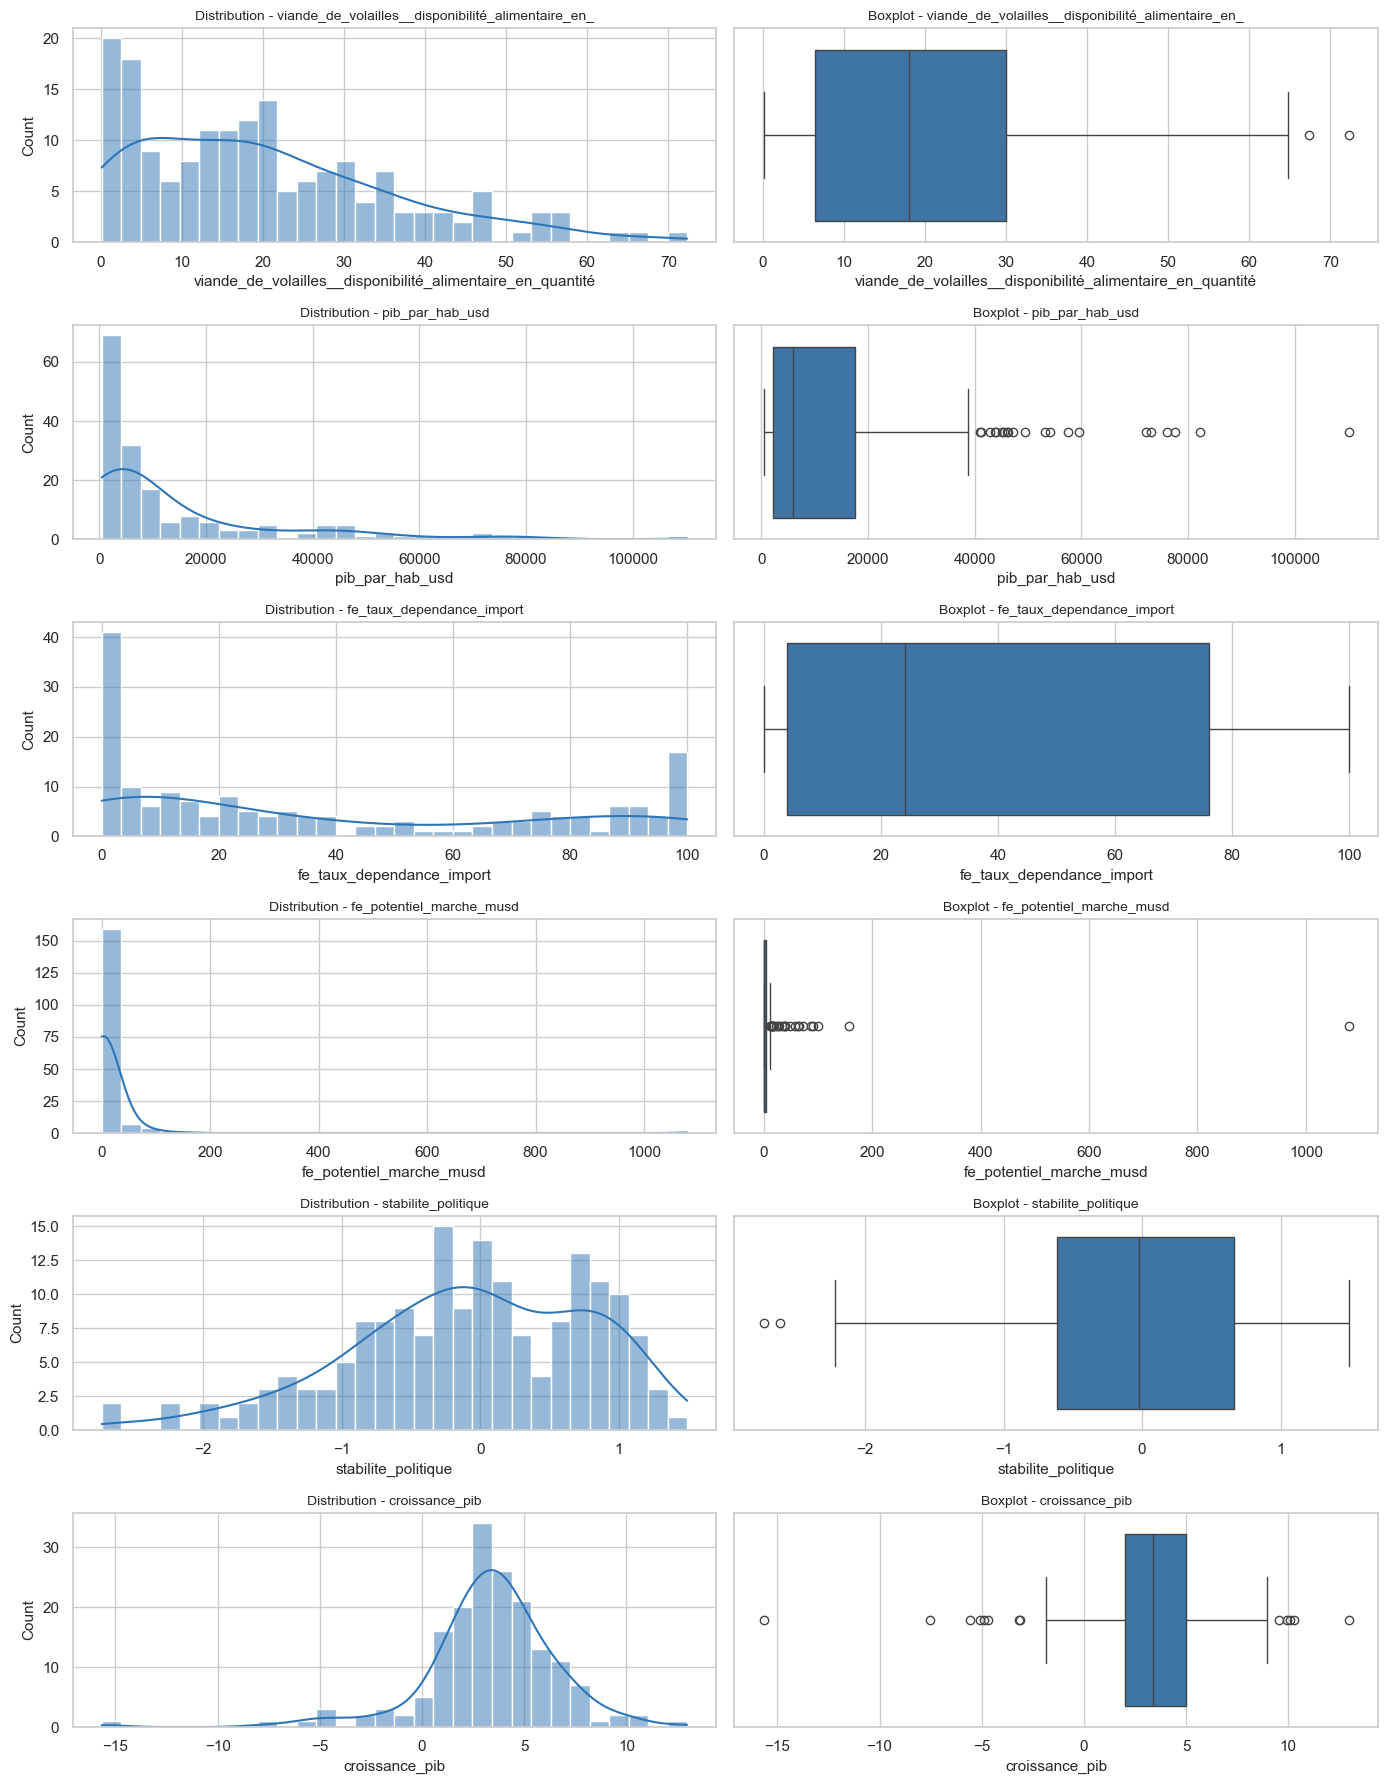

In [26]:
# un histogramme et un boxplot par variable, figure exportee pour la soutenance
vars_to_plot = [c_dispo_kg, 'pib_par_hab_usd', 'fe_taux_dependance_import',
                'fe_potentiel_marche_musd', 'stabilite_politique', 'croissance_pib']
vars_to_plot = [v for v in vars_to_plot if v in df_final.columns]

fig, axes = plt.subplots(len(vars_to_plot), 2, figsize=(14, 3 * len(vars_to_plot)))
for i, v in enumerate(vars_to_plot):
    sns.histplot(df_final[v], ax=axes[i, 0], color='#2E75B6', kde=True, bins=30)
    axes[i, 0].set_title(f'Distribution - {v[:50]}', fontsize=10)
    sns.boxplot(x=df_final[v], ax=axes[i, 1], color='#2E75B6')
    axes[i, 1].set_title(f'Boxplot - {v[:50]}', fontsize=10)
plt.tight_layout()
plt.savefig(FIG / '02_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.3 Détection des outliers (méthode IQR)

Valeurs au-delà de 1,5 écart interquartile. On tombe sur les pays riches (21 en PIB par habitant) et les géants démographiques (18 en population) : de vrais marchés, pas des erreurs, on les garde. La standardisation du notebook 2 les remettra à l'échelle.

In [27]:
# bornes IQR : quartiles -/+ 1.5 fois l'ecart interquartile
def detect_outliers_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return s[(s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)]

for v in ['pib_par_hab_usd', 'population_2017_milliers', 'fe_potentiel_marche_musd']:
    if v in df_final.columns:
        out = detect_outliers_iqr(df_final[v])
        if len(out) > 0:
            ex = df_final.loc[out.index, 'pays'].head(6).tolist()
            print(f'{v:35s} : {len(out):3d} outliers - exemples : {ex}')

pib_par_hab_usd                     :  21 outliers - exemples : ['Germany', 'Australia', 'Austria', 'Belgium', 'Canada', 'Hong Kong SAR, China']
population_2017_milliers            :  18 outliers - exemples : ['Germany', 'Bangladesh', 'Brazil', 'China', 'Russian Federation', 'India']
fe_potentiel_marche_musd            :  25 outliers - exemples : ['South Africa', 'Germany', 'Saudi Arabia', 'Argentina', 'Australia', 'Brazil']


In [28]:
# extremes de croissance : qui sont-ils ? (question probable en session)
cols = ['pays', 'croissance_pib']
display(df_final.nsmallest(3, 'croissance_pib')[cols])
display(df_final.nlargest(3, 'croissance_pib')[cols])

,pays,croissance_pib
161,"Venezuela, RB",-15.67
44,Dominica,-7.54
37,"Congo, Rep.",-5.59


,pays,croissance_pib
94,Malta,12.97
59,Guinea,10.30
70,Ireland,10.11


### 11.4 Matrice de corrélations

Corrélations de Pearson, triangle inférieur annoté. Le PIB par habitant va avec la consommation de volaille, le potentiel se recoupe avec la population et les imports. Ces redondances sont l'argument chiffré de l'ACP du notebook 2.

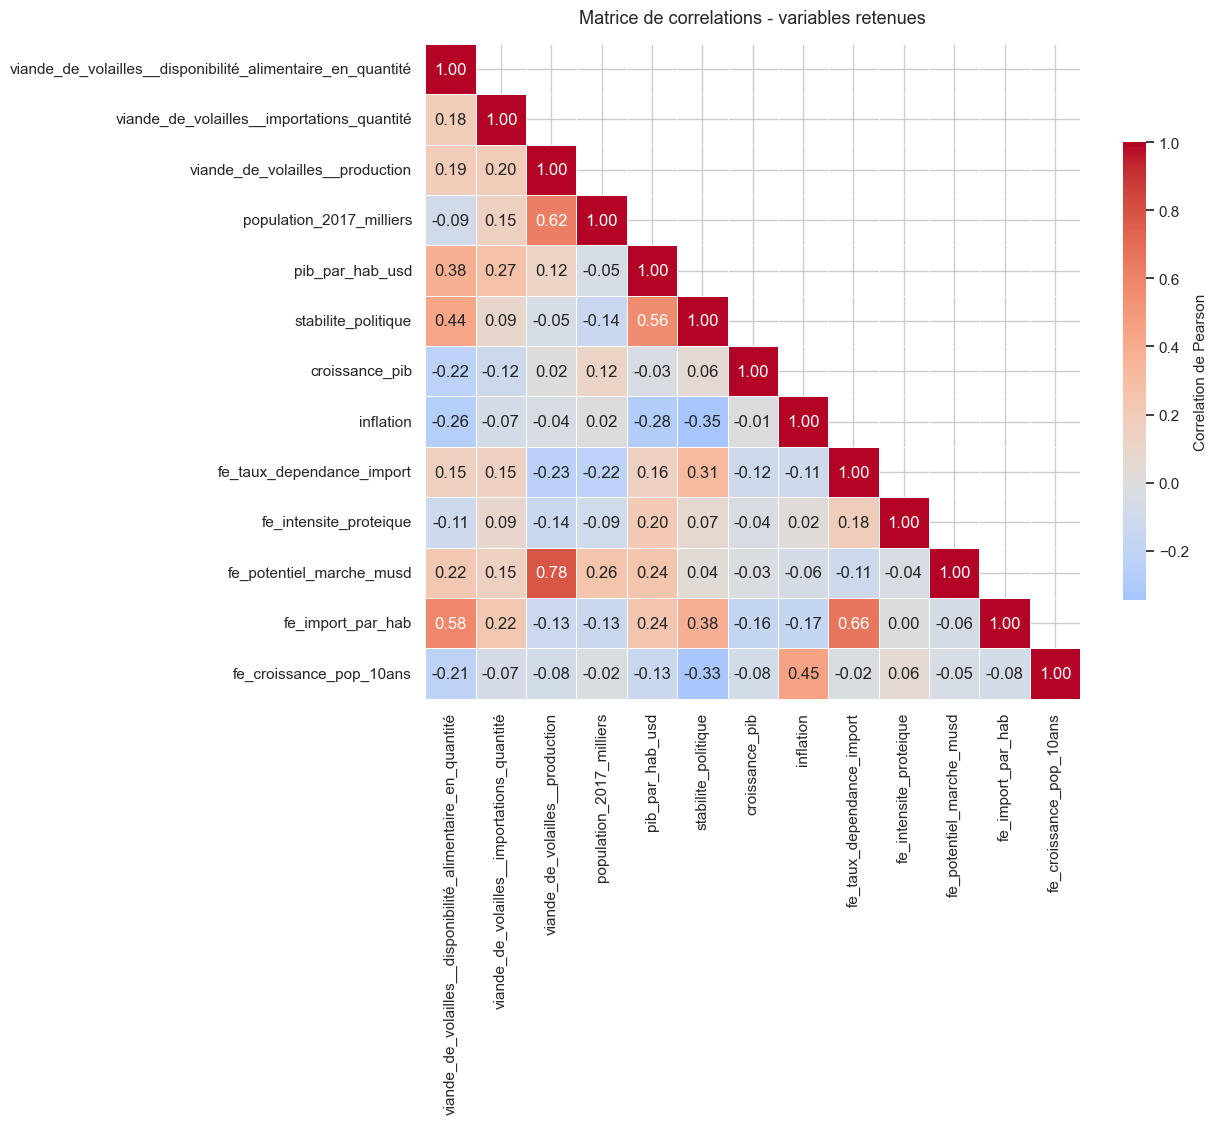

In [29]:
# corrélations de Pearson, triangle inferieur seulement (masque)
corr = df_final[vars_num].corr()
fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7, 'label': 'Correlation de Pearson'}, ax=ax)
ax.set_title('Matrice de correlations - variables retenues', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIG / '03_corr_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.5 PIB par habitant vs Disponibilite de volaille

Richesse contre consommation, échelle log, taille des points selon la population, top 10 annoté. La relation est croissante et nette : les grands marchés riches se détachent en haut à droite, la zone visée par le projet.

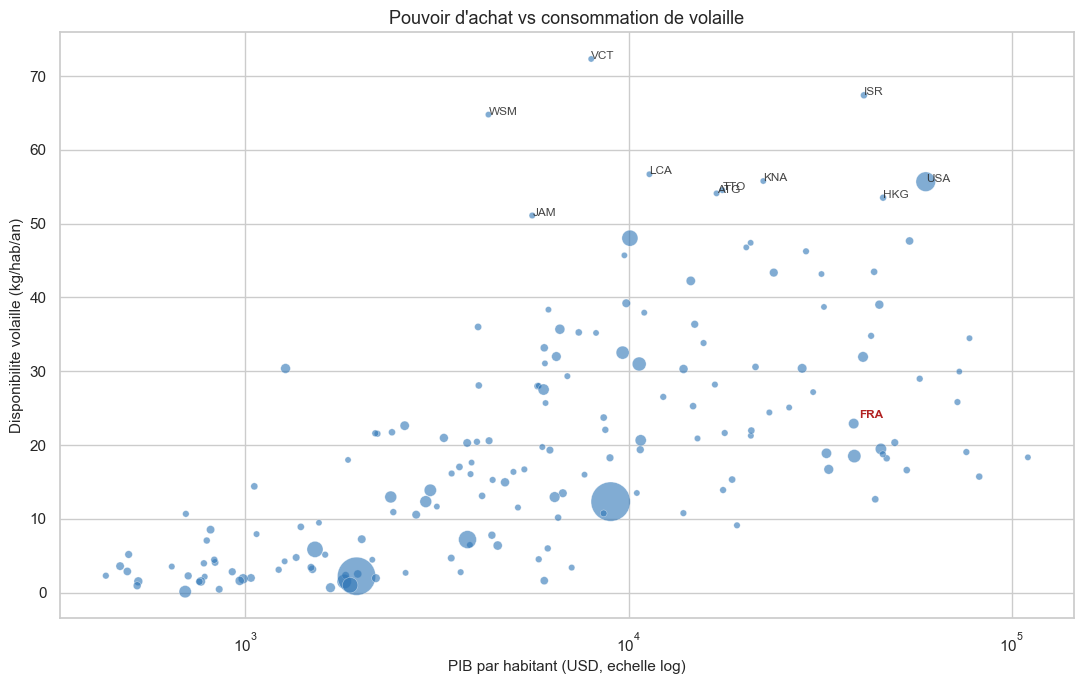

In [30]:
# echelle log en x, taille des points selon la population, top 10 annote
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=df_final, x='pib_par_hab_usd', y=c_dispo_kg,
                size='population_2017_milliers', sizes=(20, 800),
                alpha=0.6, color='#2E75B6', ax=ax, legend=False)
ax.set_xscale('log')
ax.set_xlabel('PIB par habitant (USD, echelle log)')
ax.set_ylabel('Disponibilite volaille (kg/hab/an)')
ax.set_title("Pouvoir d'achat vs consommation de volaille")
top10 = df_final.nlargest(10, c_dispo_kg)
for _, r in top10.iterrows():
    ax.annotate(r['iso3'], (r['pib_par_hab_usd'], r[c_dispo_kg]), fontsize=8.5, alpha=0.85)
plt.tight_layout()

# reperer la France : bon marche, mais domestique
fra = df_final[df_final['iso3'] == 'FRA'].iloc[0]
ax.annotate('FRA', (fra['pib_par_hab_usd'], fra[c_dispo_kg]), fontsize=8.5,
            color='firebrick', fontweight='bold', xytext=(4, 4), textcoords='offset points')

plt.savefig(FIG / '04_pib_vs_volaille.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.6 Top 20 - potentiel de marché volaille

Le classement mono-critère du potentiel. Les États-Unis loin devant, la Chine et le Japon suivent, puis l'Europe riche. Un avant-goût du cluster cible, que le clustering multi-critères confirmera ou nuancera.

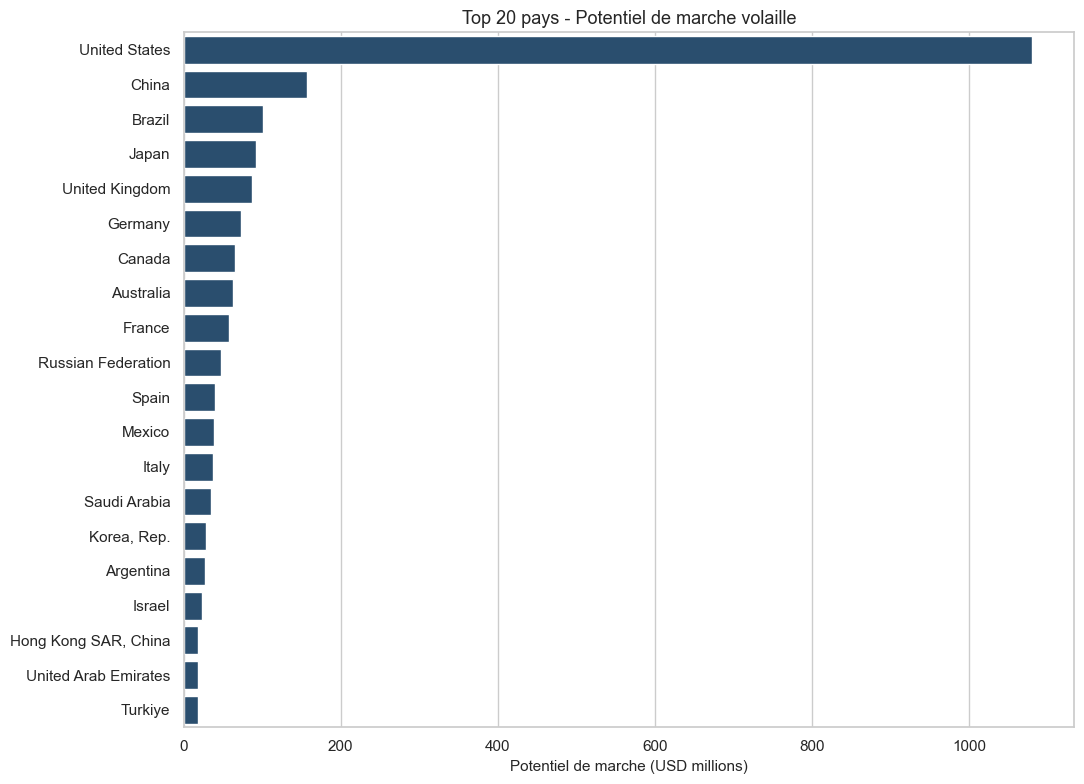

In [31]:
# top 20 du potentiel, barres triees
top20 = df_final.nlargest(20, 'fe_potentiel_marche_musd')[['pays', 'fe_potentiel_marche_musd']]
fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(data=top20, x='fe_potentiel_marche_musd', y='pays', color='#1F4E79', ax=ax)
ax.set_xlabel('Potentiel de marche (USD millions)')
ax.set_ylabel('')
ax.set_title('Top 20 pays - Potentiel de marche volaille')
plt.tight_layout()
plt.savefig(FIG / '05_top20_potentiel.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Export du dataset analytique

In [32]:
out = DATA_PROCESSED / 'dataset_p11_clean.csv'
df_final.to_csv(out, index=False)
print(f'Dataset exporte : {out.relative_to(RACINE).as_posix()}')
print(f'  - {df_final.shape[0]} pays')
print(f'  - {df_final.shape[1] - 2} variables analytiques')
print(f'  - {sum(c.startswith("fe_") for c in df_final.columns)} variables de feature engineering')
df_final.head()

Dataset exporte : data/processed/dataset_p11_clean.csv
  - 172 pays
  - 13 variables analytiques
  - 5 variables de feature engineering


,iso3,pays,viande_de_volailles__disponibilité_alimentaire_en_quantité,viande_de_volailles__importations_quantité,viande_de_volailles__production,population_2017_milliers,pib_par_hab_usd,stabilite_politique,croissance_pib,inflation,fe_taux_dependance_import,fe_intensite_proteique,fe_potentiel_marche_musd,fe_import_par_hab,fe_croissance_pop_10ans
0,AFG,Afghanistan,1.53,29.00,28.00,"36,296.11",525.47,-2.61,2.65,4.98,50.88,10.80,0.03,0.80,33.93
1,ZAF,South Africa,35.69,514.00,"1,667.00","57,009.76","6,618.34",-0.38,1.16,5.19,24.27,9.87,13.47,9.02,16.06
2,ALB,Albania,16.36,38.00,13.00,"2,884.17","5,006.36",0.16,3.28,1.99,74.51,7.36,0.24,13.18,-4.94
3,DZA,Algeria,6.38,2.00,275.00,"41,389.19","4,554.67",-0.93,1.50,5.59,0.72,8.95,1.20,0.05,21.14
4,DEU,Germany,19.47,842.00,"1,514.00","82,658.41","45,553.93",0.70,2.80,1.51,49.24,11.21,73.31,10.19,1.70


---
## Conclusion

Le dataset est prêt : dataset_p11_clean.csv, 172 pays, 13 variables analytiques, aucune valeur manquante. La disponibilité de protéines a été retirée après revue de la matrice de corrélations avec le mentor : corrélée à 0,99 avec la version en kilos, simple conversion d'unité. Les contraintes du brief sont vérifiées en code et affichées OK. Les figures sont dans outputs/figures, le relevé live dans enrichissement_live.csv, les taux par pays dans fx_par_pays.csv. La suite, ACP et clustering, se passe dans le notebook 2.